# African Credit Scoring Challenge

---

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42

---
## Step 1 — Problem Framing

**Main goal:** A private asset manager operating in several African financial markets wants to predict which borrowers are likely to default on their loan, in order to reduce financial losses and make better lending decisions.

**Can we solve it without ML?** Simple rules (e.g. reject all loans above a threshold amount) are too rigid and inaccurate. ML is justified here.

**Technical formulation:**
- Task: Binary classification — predict `Target ∈ {0, 1}` where `1 = loan default`
- Input: financial and loan data (amount, duration, country, dates...)
- Output: predicted default label
- Performance metric: **F1-Score** (appropriate for imbalanced classes — balances precision and recall)
- Non-ML baseline: always predict 0 (majority class) → F1 = 0 on class 1, useless

**Main challenge:** The dataset is heavily imbalanced (~98% non-default, ~2% default). The model must also generalize to countries not seen during training.

---
## Step 2 — Data Collection

The data is provided by Zindi. We load it and immediately check its quality:
- Size and shape
- Missing values
- Whether train and test share the same distribution (sampling bias check)
- Label distribution

> Download `Train.csv`, `Test.csv` and `SampleSubmission.csv` from [Zindi](https://zindi.africa/competitions/african-credit-scoring-challenge/data) and place them in the same folder as this notebook.

In [2]:
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
print('\nMissing values in Train:')
print(train.isnull().sum()[train.isnull().sum() > 0])
train.head()

Train shape: (68654, 16)
Test shape:  (18594, 15)

Missing values in Train:
Series([], dtype: int64)


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
0,ID_266671248032267278,266671,Kenya,248032,267278,Type_1,8448.0,8448.0,2022-08-30,2022-09-06,7,Repeat Loan,120.85,0.014305,121.0,0
1,ID_248919228515267278,248919,Kenya,228515,267278,Type_1,25895.0,25979.0,2022-07-30,2022-08-06,7,Repeat Loan,7768.50,0.300000,7794.0,0
2,ID_308486370501251804,308486,Kenya,370501,251804,Type_7,6900.0,7142.0,2024-09-06,2024-09-13,7,Repeat Loan,1380.00,0.200000,1428.0,0
3,ID_266004285009267278,266004,Kenya,285009,267278,Type_1,8958.0,9233.0,2022-10-20,2022-10-27,7,Repeat Loan,2687.40,0.300000,2770.0,0
4,ID_253803305312267278,253803,Kenya,305312,267278,Type_1,4564.0,4728.0,2022-11-28,2022-12-05,7,Repeat Loan,1369.20,0.300000,1418.0,0


Target distribution:
target
0    67396
1     1258
Name: count, dtype: int64
Default rate: 1.83%


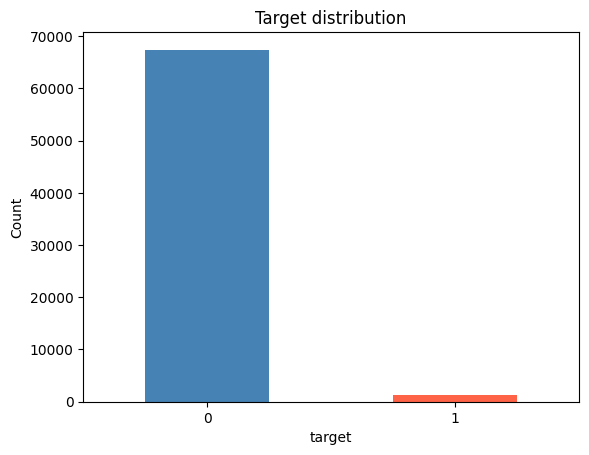

In [3]:
# Label distribution
TARGET = 'target'  # adapt column name if needed
ID     = 'ID'

print('Target distribution:')
print(train[TARGET].value_counts())
print(f'Default rate: {train[TARGET].mean()*100:.2f}%')

train[TARGET].value_counts().plot(kind='bar', color=['steelblue','tomato'],
                                   title='Target distribution', rot=0)
plt.ylabel('Count')
plt.show()

In [4]:
# Check for distribution shift: are all countries in train also in test?
if 'country' in train.columns:
    new_countries = set(test['country'].unique()) - set(train['country'].unique())
    print(f'Countries only in test (unseen during training): {new_countries}')

---
## Step 3 — Data Wrangling

We transform the raw data into a format suitable for training:
- **Date columns** → extract year, month, day (numeric)
- **Categorical columns** → label encoding (LightGBM handles integers natively)
- **Missing values** → filled with the median
- **Feature engineering** → loan term in days, repayment ratio (new informative features from raw data)

To avoid **data leakage**, we combine train and test before transforming, so both get consistent encodings — but we never use test labels (there are none) and no statistics are computed from the test set.

In [14]:
y        = train[TARGET].copy()
test_ids = test[ID].copy()

train_df = train.drop(columns=[TARGET, ID])
test_df  = test.drop(columns=[ID])

n_train = len(train_df)
df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# Feature engineering: dates 
date_cols = []
for col in df.select_dtypes(include='object').columns:
    try:
        parsed = pd.to_datetime(df[col], errors='raise')
        df[col + '_year']  = parsed.dt.year
        df[col + '_month'] = parsed.dt.month
        df[col + '_day']   = parsed.dt.day
        date_cols.append(col)
    except Exception:
        pass
df = df.drop(columns=date_cols)

if 'disbursement_date_year' in df.columns and 'due_date_year' in df.columns:
    # approximate term in months
    df['loan_term_months'] = (df['due_date_year'] - df['disbursement_date_year']) * 12 + \
                             (df['due_date_month'] - df['disbursement_date_month'])

if 'total_amount' in df.columns and 'loan_amount' in df.columns:
    df['repayment_ratio'] = df['total_amount'] / (df['loan_amount'] + 1e-9)

# Encode remaining categoricals 
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Fill missing values 
df = df.fillna(df.median(numeric_only=True))

X_train = df.iloc[:n_train].copy()
X_test  = df.iloc[n_train:].copy()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print('\nSample of engineered features:')
X_train.head(3)

X_train: (68654, 19)  |  X_test: (18594, 19)

Sample of engineered features:


,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,disbursement_date_year,disbursement_date_month,disbursement_date_day,due_date_year,due_date_month,due_date_day,loan_term_months
0,266671,1,248032,267278,0,8448.0,8448.0,7,1,120.85,0.014305,121.0,2022,8,30,2022,9,6,1
1,248919,1,228515,267278,0,25895.0,25979.0,7,1,7768.50,0.300000,7794.0,2022,7,30,2022,8,6,1
2,308486,1,370501,251804,21,6900.0,7142.0,7,1,1380.00,0.200000,1428.0,2024,9,6,2024,9,13,0


---
## Step 4 — Data Analysis (EDA)

Before training, we explore the data to:
- Understand feature distributions
- Identify which features correlate most with the target
- Detect potential outliers
- Compare the distribution of features between defaulters and non-defaulters



In [6]:
# Summary statistics
X_train.describe().T[['mean','std','min','max']].round(2)

,mean,std,min,max
customer_id,254390.26,26642.72,145.0,312737.00
country_id,1.00,0.00,1.0,1.00
tbl_loan_id,263056.27,39486.66,101323.0,375320.00
lender_id,266420.53,3591.00,245684.0,267278.00
loan_type,1.82,5.70,0.0,23.00
Total_Amount,14836.83,141649.87,2.0,23000000.00
Total_Amount_to_Repay,15639.93,165078.35,0.0,25415000.00
duration,8.54,13.34,1.0,1096.00
New_versus_Repeat,0.99,0.09,0.0,1.00
Amount_Funded_By_Lender,2545.66,11922.72,0.0,1600000.00


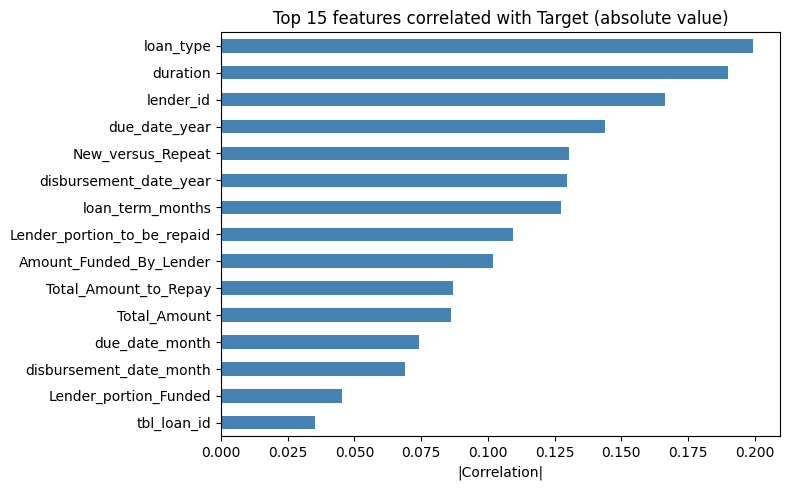

In [7]:
# Top features most correlated with target
corr = X_train.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
corr.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 15 features correlated with Target (absolute value)')
ax.set_xlabel('|Correlation|')
plt.tight_layout()
plt.show()

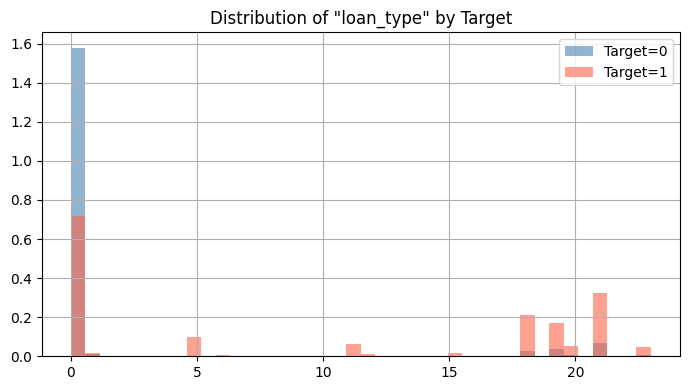

In [8]:
# Distribution of a key feature split by target
key_feat = corr.index[0]  # most correlated feature

fig, ax = plt.subplots(figsize=(7, 4))
for label, color in zip([0, 1], ['steelblue', 'tomato']):
    X_train.loc[y == label, key_feat].hist(bins=40, alpha=0.6, label=f'Target={label}',
                                            color=color, ax=ax, density=True)
ax.set_title(f'Distribution of "{key_feat}" by Target')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 5 — Model Training & Evaluation

Following the lifecycle guidelines:
- We **start simple** (just LightGBM with sensible defaults before tuning)
- We use **StratifiedKFold** cross-validation to evaluate on held-out data, keeping the class ratio balanced in each fold
- We tune the **decision threshold** (not always 0.5) to maximize F1-Score on the validation set
- We look at **feature importance** to understand the model and detect potential issues

LightGBM is a gradient boosting model: it builds many weak decision trees sequentially, each one correcting the errors of the previous. We handle the class imbalance via `scale_pos_weight`.

In [9]:
# Class imbalance weight
neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos_weight = neg / pos
print(f'Non-default: {neg}  |  Default: {pos}  |  scale_pos_weight: {scale_pos_weight:.1f}')

Non-default: 67396  |  Default: 1258  |  scale_pos_weight: 53.6


In [10]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    verbose=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
f1_scores  = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model.fit(X_tr, y_tr)

    val_proba = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_proba
    test_preds += model.predict_proba(X_test)[:, 1] / 5

    # Find best threshold for F1 on this fold
    thresholds = np.linspace(0.01, 0.99, 200)
    f1s = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
    best_f1 = max(f1s)
    best_t  = thresholds[np.argmax(f1s)]
    f1_scores.append(best_f1)

    print(f'Fold {fold+1}/5 — F1: {best_f1:.4f}  (best threshold: {best_t:.2f})')

print(f'\nMean CV F1: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}')

Fold 1/5 — F1: 0.8008  (best threshold: 0.41)
Fold 2/5 — F1: 0.8486  (best threshold: 0.54)
Fold 3/5 — F1: 0.8170  (best threshold: 0.68)
Fold 4/5 — F1: 0.8124  (best threshold: 0.64)
Fold 5/5 — F1: 0.8035  (best threshold: 0.70)

Mean CV F1: 0.8165 ± 0.0171


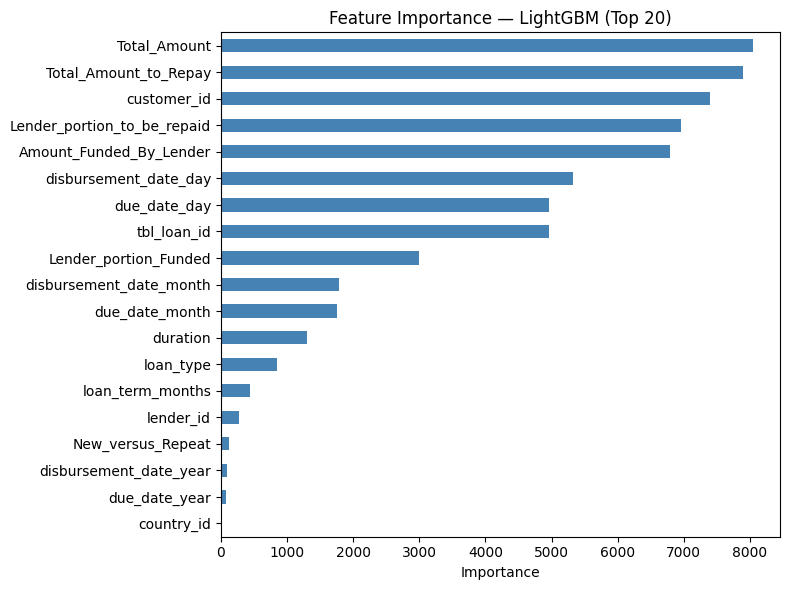

In [11]:
# Feature importance — helps validate data quality and detect leakage
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Feature Importance — LightGBM (Top 20)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

---
## Step 6 — Model Deployment (Submission)

The final step is generating predictions on the test set and producing the submission file.

In a real production setting, deployment would also include:
- Versioning the model and data as code
- Testing each component of the pipeline
- Monitoring for training-serving skew (the model may degrade if the real-world data distribution shifts over time)
- Periodically retraining on new data

Here, we apply the **global best threshold** found on the full out-of-fold predictions, then save the submission file.

In [12]:
# Find the global best threshold on full OOF predictions
thresholds = np.linspace(0.01, 0.99, 200)
f1s = [f1_score(y, (oof_preds >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1s)]
print(f'Global best threshold: {best_thresh:.3f}  |  OOF F1: {max(f1s):.4f}')

# Generate final predictions
final_preds = (test_preds >= best_thresh).astype(int)
print(f'Predicted defaults: {final_preds.sum()} / {len(final_preds)} ({final_preds.mean()*100:.2f}%)')

# Save submission file
submission = pd.DataFrame({'ID': test_ids, 'Target': final_preds})
submission.to_csv('submission.csv', index=False)
print('\nsubmission.csv saved')
submission.head()

Global best threshold: 0.719  |  OOF F1: 0.8102
Predicted defaults: 671 / 18594 (3.61%)

submission.csv saved ✅


,ID,Target
0,ID_269404226088267278,0
1,ID_255356300042267278,0
2,ID_257026243764267278,0
3,ID_264617299409267278,0
4,ID_247613296713267278,0
